# 03 — Momentum Alpha Sweep

Systematically test momentum templates across a range of fields and lookback windows.

## Momentum intuition

Momentum alphas capture the idea that stocks that have recently done well (or badly)
continue to do so. In Brain expressions:

- `ts_rank(close, 20)` — long stocks whose price has trended up over 20 days
- `ts_zscore(returns, 10)` — long stocks with abnormally high recent returns
- `-ts_corr(rank(close), rank(volume), 10)` — long stocks where price rises aren't accompanied by volume (accumulation pattern)

## Strategy

1. Pick a set of fields (close, returns, volume, vwap)
2. Apply each momentum template with windows [5, 10, 20]
3. Submit all combinations to Brain
4. Identify which field × window × template combinations score best

In [1]:
import sys
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from wq.client import get_client, simulate
from wq.alpha import AlphaConfig, momentum_alphas, MOMENTUM_TEMPLATES, expand_templates
from wq.utils import load_results, top_alphas, parse_result

client = get_client()

Authenticated as jayesh.s@alumni.iitgn.ac.in


## Define the sweep

Edit `FIELDS` and `WINDOWS` to control the sweep scope.

In [2]:
# Fields to test — these are standard Brain field IDs
FIELDS = ['close', 'returns', 'volume', 'vwap']
WINDOWS = [5, 10, 20]
LONG_WINDOW = 60  # for dual-window templates

# Shared simulation settings for the sweep
SIM_SETTINGS = dict(
    universe='TOP3000',
    region='USA',
    neutralization='Subindustry',
    delay=1,
    decay=0,
)

# Generate all alpha configs
all_configs = []
for field in FIELDS:
    for window in WINDOWS:
        for expr in expand_templates(MOMENTUM_TEMPLATES, field, window=window, long_window=LONG_WINDOW):
            all_configs.append(AlphaConfig(
                expression=expr,
                tags=['momentum', field, f'w{window}'],
                notes=f'Momentum sweep: {field}, window={window}',
                **SIM_SETTINGS,
            ))

print(f'Total alphas to test: {len(all_configs)}')
for c in all_configs[:5]:
    print(f'  {c.expression}')

Total alphas to test: 48
  ts_rank(close, 5)
  ts_zscore(close, 5)
  -1 * ts_corr(rank(close), rank(volume), 5)
  ts_rank(close, 5) - ts_rank(close, 60)
  ts_rank(close, 10)


## Run the sweep

**Warning:** each simulation takes 2–5 minutes. For a full sweep of 48 alphas that's
2–4 hours of sequential submissions. Consider batching overnight or narrowing the
field/window selection first.

The loop saves every result to `data/results.csv` as it completes — you can stop
and resume safely.

In [3]:
# Skip alphas we've already submitted (matched by fingerprint)
existing = load_results()
done_fingerprints = set(existing['fingerprint'].dropna().tolist()) if not existing.empty else set()

to_run = [c for c in all_configs if c.fingerprint() not in done_fingerprints]
print(f'{len(done_fingerprints)} already run, {len(to_run)} remaining')

2 already run, 47 remaining


In [4]:
results = []

for config in tqdm(to_run, desc='Submitting alphas'):
    try:
        result = simulate(client, config, save=True)
        metrics = parse_result(result)
        results.append({'expression': config.expression, **metrics})
        sharpe = metrics.get('is_sharpe') or 0
        fitness = metrics.get('is_fitness') or 0
        print(f'  sharpe={sharpe:.3f}  fitness={fitness:.3f}')
    except Exception as e:
        print(f'  ERROR: {e}')
        results.append({'expression': config.expression, 'error': str(e)})

print(f'\nDone. {len(results)} results.')

Submitting alphas:   0%|          | 0/47 [00:00<?, ?it/s]

Submitting: ts_rank(close, 5)
  sim_id=3V1owkdaf4zhaZt1gilZN9PK — polling every 10s...
  status=COMPLETE
  sharpe=-2.000  fitness=-0.810
Submitting: ts_zscore(close, 5)
  sim_id=1EorMN95a5d4cdmbqZZBOVF — polling every 10s...
  status=COMPLETE
  sharpe=-2.000  fitness=-0.840
Submitting: -1 * ts_corr(rank(close), rank(volume), 5)
  sim_id=zjNmC3Ro501bsE1dAQMpdou — polling every 10s...
  status=COMPLETE
  sharpe=0.740  fitness=0.130
Submitting: ts_rank(close, 5) - ts_rank(close, 60)
  sim_id=KptNb7y04xibax1bJsEdVbC — polling every 10s...
  status=COMPLETE
  sharpe=-1.090  fitness=-0.340
Submitting: ts_rank(close, 10)
  sim_id=4l9mio6NJ5htbFz17OAPuiYv — polling every 10s...
  status=COMPLETE
  sharpe=-1.790  fitness=-0.840
Submitting: ts_zscore(close, 10)
  sim_id=15khGgamp4psbhXDDFb9vak — polling every 10s...
  status=COMPLETE
  sharpe=-1.800  fitness=-0.900
Submitting: -1 * ts_corr(rank(close), rank(volume), 10)
  sim_id=3s9Hkif9f4qmcJsF370eQmc — polling every 10s...
  status=COMPLETE
  

## Analyse results

In [5]:
import matplotlib.pyplot as plt

# Load all momentum results (tag filter)
all_results = load_results()
momentum_results = all_results[all_results['tags'].str.contains('momentum', na=False)].copy()
print(f'{len(momentum_results)} momentum results in log')

momentum_results = momentum_results.dropna(subset=['is_sharpe', 'is_fitness'])
momentum_results = momentum_results.sort_values('is_fitness', ascending=False)
momentum_results.head(15)

54 momentum results in log


,sim_id,status,expression,fingerprint,tags,universe,neutralization,delay,decay,is_sharpe,is_fitness,is_returns,is_turnover,is_drawdown,os_sharpe,os_fitness,os_returns,os_turnover,notes
52,2mQcPncvx4T5bVKJlQxjXWb,COMPLETE,"-1 * ts_corr(rank(vwap), rank(volume), 20)",63fafe8e129fc701,"[""momentum"", ""vwap"", ""w20""]",TOP3000,Subindustry,1,0,1.10,0.45,0.0465,0.2808,0.0626,NaN,NaN,NaN,NaN,"Momentum sweep: vwap, window=20"
17,4arre97kP4Tc8ZKz35nZRyf,COMPLETE,"-1 * ts_corr(rank(close), rank(volume), 20)",dd24e799d5a9e597,"[""momentum"", ""close"", ""w20""]",TOP3000,Subindustry,1,0,0.93,0.35,0.0397,0.2804,0.0721,NaN,NaN,NaN,NaN,"Momentum sweep: close, window=20"
24,1mpc5J9Ot4k18XAz6N5ysJX,COMPLETE,"-1 * ts_corr(rank(returns), rank(volume), 10)",a1fc526ec9eb56ae,"[""momentum"", ""returns"", ""w10""]",TOP3000,Subindustry,1,0,1.04,0.28,0.0335,0.4690,0.0518,NaN,NaN,NaN,NaN,"Momentum sweep: returns, window=10"
28,3YsTY147z5ba9dmoH52qhsg,COMPLETE,"-1 * ts_corr(rank(returns), rank(volume), 20)",2485a15403a3def0,"[""momentum"", ""returns"", ""w20""]",TOP3000,Subindustry,1,0,0.78,0.23,0.0275,0.3264,0.0413,NaN,NaN,NaN,NaN,"Momentum sweep: returns, window=20"
21,4rEkqd3CL5b79LFqEOLeM05,COMPLETE,"ts_rank(returns, 5) - ts_rank(returns, 60)",72aedc7063ca7c8b,"[""momentum"", ""returns"", ""w5""]",TOP3000,Subindustry,1,0,1.07,0.22,0.0538,1.2347,0.0425,NaN,NaN,NaN,NaN,"Momentum sweep: returns, window=5"
44,2Gyllx1t34Cia7uXQb14e7G,COMPLETE,"-1 * ts_corr(rank(vwap), rank(volume), 5)",fab2a82dd7489bf4,"[""momentum"", ""vwap"", ""w5""]",TOP3000,Subindustry,1,0,1.00,0.21,0.0321,0.7457,0.0406,NaN,NaN,NaN,NaN,"Momentum sweep: vwap, window=5"
48,2iRyXI6Jw5hT97cdt5r59js,COMPLETE,"-1 * ts_corr(rank(vwap), rank(volume), 10)",762f0d9d075cf5a0,"[""momentum"", ""vwap"", ""w10""]",TOP3000,Subindustry,1,0,0.65,0.15,0.0242,0.4655,0.0724,NaN,NaN,NaN,NaN,"Momentum sweep: vwap, window=10"
25,fPEWHg1W5aZct2xwt7eNf9,COMPLETE,"ts_rank(returns, 10) - ts_rank(returns, 60)",e2d09da7f1b22ff3,"[""momentum"", ""returns"", ""w10""]",TOP3000,Subindustry,1,0,0.77,0.14,0.0389,1.1914,0.0572,NaN,NaN,NaN,NaN,"Momentum sweep: returns, window=10"
11,zjNmC3Ro501bsE1dAQMpdou,COMPLETE,"-1 * ts_corr(rank(close), rank(volume), 5)",a5cf1b57481f4641,"[""momentum"", ""close"", ""w5""]",TOP3000,Subindustry,1,0,0.74,0.13,0.0232,0.7384,0.0457,NaN,NaN,NaN,NaN,"Momentum sweep: close, window=5"
15,3s9Hkif9f4qmcJsF370eQmc,COMPLETE,"-1 * ts_corr(rank(close), rank(volume), 10)",ebb32674960474cf,"[""momentum"", ""close"", ""w10""]",TOP3000,Subindustry,1,0,0.55,0.12,0.0205,0.4633,0.0779,NaN,NaN,NaN,NaN,"Momentum sweep: close, window=10"


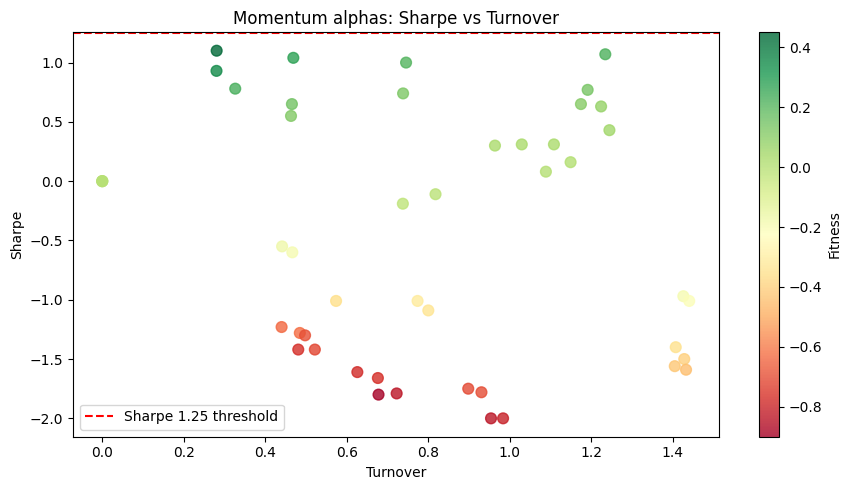

In [6]:
# Sharpe vs Turnover scatter — colour by fitness
if len(momentum_results) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    sc = ax.scatter(
        momentum_results['is_turnover'],
        momentum_results['is_sharpe'],
        c=momentum_results['is_fitness'],
        cmap='RdYlGn', s=60, alpha=0.8
    )
    plt.colorbar(sc, label='Fitness')
    ax.axhline(1.25, color='red', linestyle='--', label='Sharpe 1.25 threshold')
    ax.set_xlabel('Turnover')
    ax.set_ylabel('Sharpe')
    ax.set_title('Momentum alphas: Sharpe vs Turnover')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [7]:
# Best momentum alphas
top_alphas(momentum_results, n=10, metric='is_fitness')[['expression', 'is_sharpe', 'is_fitness', 'is_returns', 'is_turnover']]

,expression,is_sharpe,is_fitness,is_returns,is_turnover
0,"-1 * ts_corr(rank(vwap), rank(volume), 20)",1.10,0.45,0.0465,0.2808
1,"-1 * ts_corr(rank(close), rank(volume), 20)",0.93,0.35,0.0397,0.2804
2,"-1 * ts_corr(rank(returns), rank(volume), 10)",1.04,0.28,0.0335,0.4690
3,"-1 * ts_corr(rank(returns), rank(volume), 20)",0.78,0.23,0.0275,0.3264
4,"ts_rank(returns, 5) - ts_rank(returns, 60)",1.07,0.22,0.0538,1.2347
5,"-1 * ts_corr(rank(vwap), rank(volume), 5)",1.00,0.21,0.0321,0.7457
6,"-1 * ts_corr(rank(vwap), rank(volume), 10)",0.65,0.15,0.0242,0.4655
7,"ts_rank(returns, 10) - ts_rank(returns, 60)",0.77,0.14,0.0389,1.1914
8,"-1 * ts_corr(rank(close), rank(volume), 5)",0.74,0.13,0.0232,0.7384
9,"-1 * ts_corr(rank(close), rank(volume), 10)",0.55,0.12,0.0205,0.4633
